In [ ]:
---
execute:
  eval: false
  echo: true
  warning: false
format:
  html:
    code-fold: false
---

Importing the packages.

In [1]:
#| echo: true
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score

Creating a synthetic dataset.

In [2]:
#| echo: true
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=0.60, random_state=42)

Instantiating and fitting the $k$-Means algorithm with different $k$ values.

In [3]:
#| echo: true

k_range = range(2, 7)
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

Plotting the Silhouette Coefficient of the different algorithms, while showing the best result.

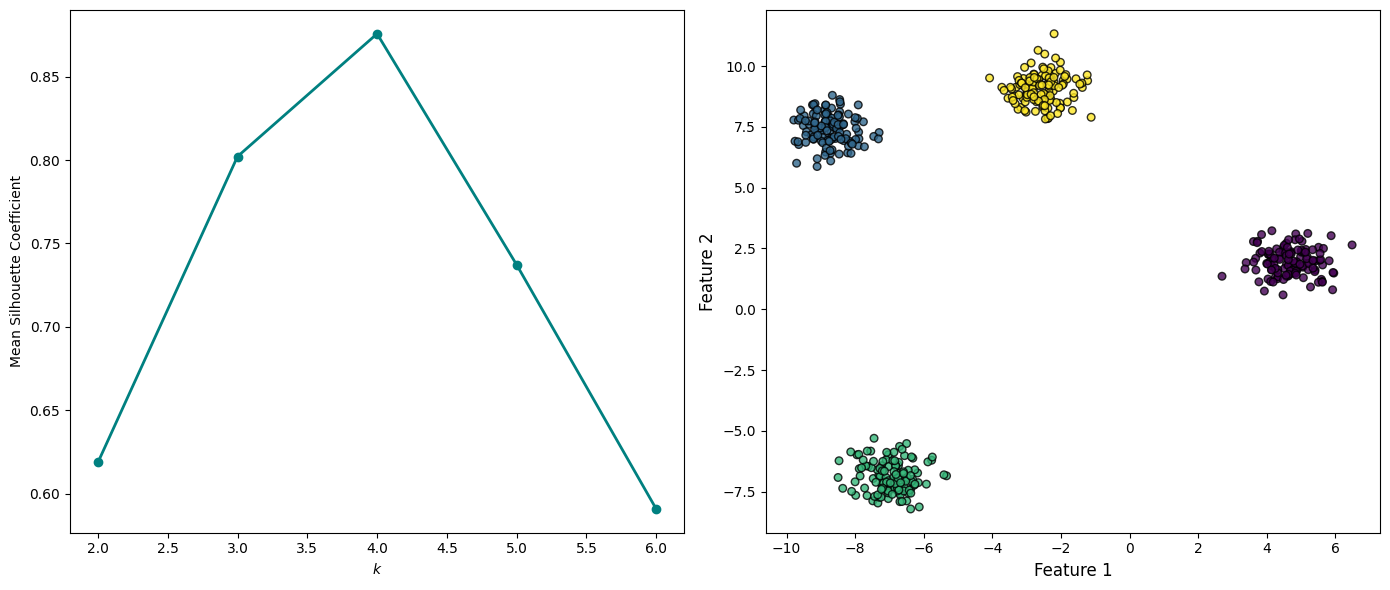

In [5]:
#| echo: true
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(k_range, silhouette_scores, marker='o', color='teal', linewidth=2)
ax1.set_xlabel(r"$k$")
ax1.set_ylabel("Mean Silhouette Coefficient")

optimal_k = 4
kmeans_opt = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
y_pred = kmeans_opt.fit_predict(X)

scatter = ax2.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=30, edgecolor='k', alpha=0.8)
ax2.set_xlabel("Feature 1")
ax2.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

Calculating the Adjusted Radn Index with the labels from the synthetic dataset.

In [7]:
#| echo: true
print("=" * 60)
print("ADJUSTED RAND INDEX (ARI)")
print("=" * 60)

y_permuted = np.zeros_like(y_pred)
y_permuted[y_pred == 0] = 2
y_permuted[y_pred == 1] = 3
y_permuted[y_pred == 2] = 0
y_permuted[y_pred == 3] = 1

ari_standard = adjusted_rand_score(y_true, y_pred)
ari_permuted = adjusted_rand_score(y_true, y_permuted)
ari_random = adjusted_rand_score(y_true, np.random.randint(0, 4, size=len(y_true)))

print(f"Standard Predictions ARI: {ari_standard:.4f}")
print(f"Permuted Labels Predictions ARI: {ari_permuted:.4f}")
print(f"Purely Random Assignments ARI: {ari_random:.4f}")
print("=" * 60)

ADJUSTED RAND INDEX (ARI)
Standard Predictions ARI: 1.0000
Permuted Labels Predictions ARI: 1.0000
Purely Random Assignments ARI: -0.0016
